1.  Cargar los 4 módulos

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

# Cargar los 4 módulos
demo  = pd.read_sas('data/DEMO_L.XPT', format='xport', encoding='utf-8')
bmx   = pd.read_sas('data/BMX_L.XPT',  format='xport', encoding='utf-8')
bpx   = pd.read_sas('data/BPXO_L.XPT',  format='xport', encoding='utf-8')
diq   = pd.read_sas('data/DIQ_L.XPT',  format='xport', encoding='utf-8')

print("✅ Módulos cargados correctamente")
print(f"Demographics:   {demo.shape}")
print(f"Body Measures:  {bmx.shape}")
print(f"Blood Pressure: {bpx.shape}")
print(f"Diabetes:       {diq.shape}")

✅ Módulos cargados correctamente
Demographics:   (11933, 27)
Body Measures:  (8860, 22)
Blood Pressure: (7801, 12)
Diabetes:       (11744, 9)


2. Unir todos los módulos en un solo dataframe

In [11]:
# La columna SEQN es el ID único del participante en todos los módulos
df = demo.merge(bmx, on='SEQN', how='left') \
         .merge(bpx, on='SEQN', how='left') \
         .merge(diq, on='SEQN', how='left')

print(f"✅ Dataset unificado")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

✅ Dataset unificado
Filas: 11933
Columnas: 67


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,BPXOPLS2,BPXOPLS3,DIQ010,DID040,DIQ160,DIQ180,DIQ050,DID060,DIQ060U,DIQ070
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,79.0,82.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,71.0,73.0,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,...,83.0,77.0,1.0,35.0,NaN,NaN,2.0,NaN,NaN,1.0
3,130381.0,12.0,2.0,2.0,5.0,NaN,5.0,7.0,1.0,71.0,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,12.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,34.0,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


3. Tipos de variables

In [12]:
numericas = df.select_dtypes(include='number').columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()

print(f"Variables numéricas: {len(numericas)}")
print(f"Variables categóricas: {len(categoricas)}")
print("\nPrimeras 10 columnas numéricas:")
print(numericas[:10])

Variables numéricas: 66
Variables categóricas: 1

Primeras 10 columnas numéricas:
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM']


C:\Users\Natalia\AppData\Local\Temp\ipykernel_13084\4110412635.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include='object').columns.tolist()


4. Valores nulos antes de imputar

In [13]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)

missing = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': porcentaje
}).sort_values('Porcentaje (%)', ascending=False)

print("=== COLUMNAS CON VALORES NULOS ===")
print(missing[missing['Valores nulos'] > 0].head(20))

=== COLUMNAS CON VALORES NULOS ===
          Valores nulos  Porcentaje (%)
BMIHEAD           11933          100.00
BMIRECUM          11915           99.85
BMXHEAD           11863           99.41
BMIHT             11799           98.88
BMIARML           11733           98.32
BMIARMC           11728           98.28
DIQ060U           11601           97.22
DID060            11590           97.13
BMIWT             11588           97.11
BMIWAIST          11586           97.09
BMIHIP            11572           96.97
RIDAGEMN          11556           96.84
BMILEG            11537           96.68
BMXRECUM          11479           96.20
DIQ050            10852           90.94
DID040            10852           90.94
RIDEXPRG          10430           87.40
DMDYRUSR          10058           84.29
DMDHSEDZ           9806           82.18
DIQ070             9652           80.88


5. Imputar con KNN

In [15]:
# Eliminar columnas constantes (un solo valor único)
cols_constantes = [col for col in numericas if df[col].nunique() <= 1]
print(f"Columnas constantes eliminadas: {cols_constantes}")

numericas_ok = [col for col in numericas if col not in cols_constantes]

# KNN para numéricas
imputer = KNNImputer(n_neighbors=5)
df_num = pd.DataFrame(
    imputer.fit_transform(df[numericas_ok]),
    columns=numericas_ok
)

# Moda para categóricas
if categoricas:
    df_cat = df[categoricas].fillna(df[categoricas].mode().iloc[0])
else:
    df_cat = pd.DataFrame()

# Reconstruir dataframe
df_limpio = pd.concat([df_num, df_cat], axis=1)

print(f"✅ Imputación completada")
print(f"Nulos restantes: {df_limpio.isnull().sum().sum()}")

Columnas constantes eliminadas: ['SDDSRVYR', 'BMIRECUM', 'BMIHEAD', 'BMILEG', 'BMIARML', 'BMIARMC', 'BMIWAIST', 'BMIHIP']
✅ Imputación completada
Nulos restantes: 0


In [9]:
print("Columnas duplicadas:", df.columns[df.columns.duplicated()].tolist())
print("Total columnas numéricas:", len(numericas))
print("Columnas únicas numéricas:", len(set(numericas)))

Columnas duplicadas: []
Total columnas numéricas: 66
Columnas únicas numéricas: 66


6. Estadísticas descriptivas

In [16]:
df_limpio.describe().round(2)

,SEQN,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,...,BPXOPLS2,BPXOPLS3,DIQ010,DID040,DIQ160,DIQ180,DIQ050,DID060,DIQ060U,DIQ070
count,11933.0,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,...,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00,11933.00
mean,136344.0,1.74,1.53,38.32,11.56,3.10,3.32,1.47,151.98,1.92,...,73.21,74.06,1.94,69.93,1.90,1.83,1.69,35.97,1.86,1.64
std,3444.9,0.44,0.50,25.60,3.16,1.08,1.52,0.46,47.21,0.25,...,10.98,11.17,0.36,73.21,0.38,1.21,0.24,69.38,0.16,0.36
min,130378.0,1.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,...,32.00,31.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,133361.0,1.00,1.00,13.00,9.80,3.00,3.00,1.00,125.80,2.00,...,66.00,67.00,2.00,45.00,2.00,1.00,1.60,8.00,1.80,1.40
50%,136344.0,2.00,2.00,37.00,11.40,3.00,3.00,1.40,158.60,2.00,...,73.00,74.00,2.00,50.00,2.00,1.80,1.80,11.80,2.00,1.60
75%,139327.0,2.00,2.00,62.00,13.40,4.00,4.00,2.00,188.80,2.00,...,79.00,80.80,2.00,56.20,2.00,2.00,1.80,17.00,2.00,1.80
max,142310.0,2.00,2.00,80.00,24.00,5.00,7.00,2.00,239.00,7.00,...,141.00,154.00,9.00,999.00,9.00,9.00,2.00,999.00,2.00,9.00


7. Distribución de IMC (BMXBMI)

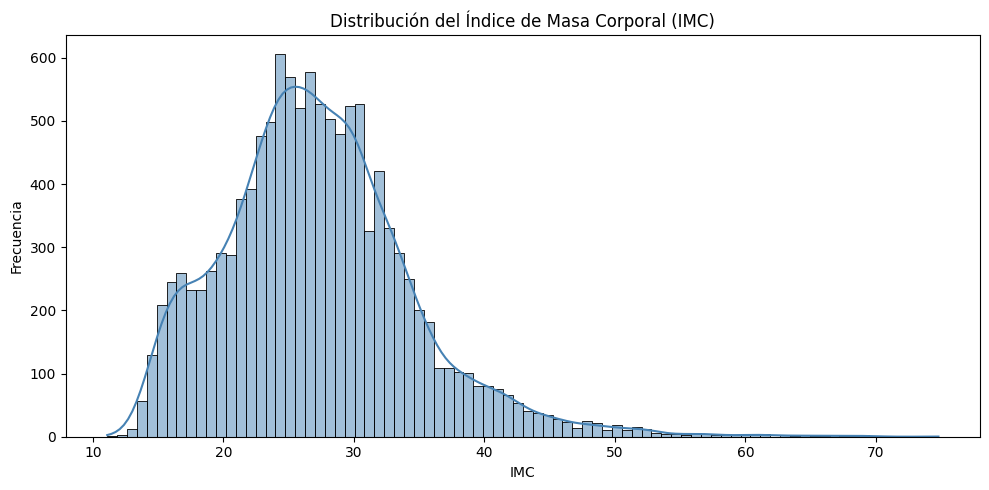

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df_limpio['BMXBMI'], kde=True, color='steelblue')
plt.title('Distribución del Índice de Masa Corporal (IMC)')
plt.xlabel('IMC')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

8. Distribución de edad (RIDAGEYR)

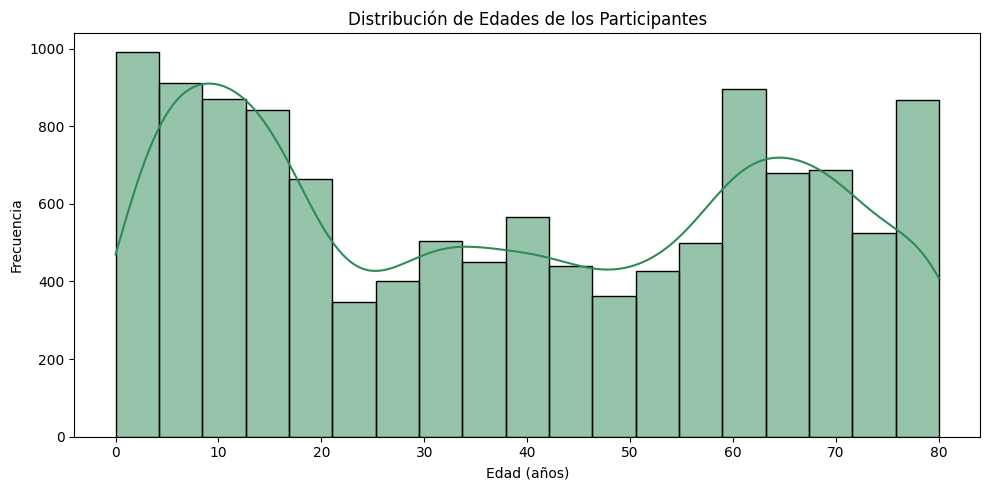

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df_limpio['RIDAGEYR'], kde=True, color='seagreen')
plt.title('Distribución de Edades de los Participantes')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

9. Presión arterial sistólica vs IMC

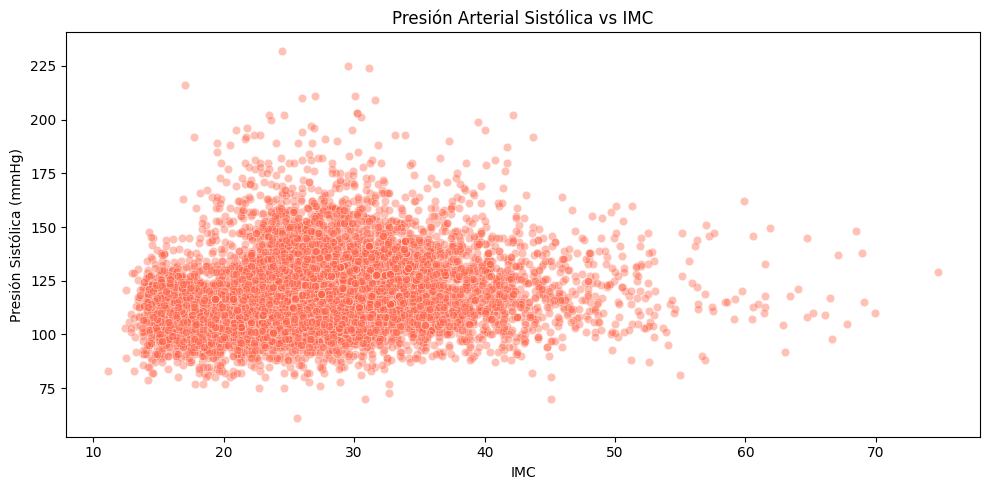

In [21]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_limpio,
    x='BMXBMI',
    y='BPXOSY1',
    alpha=0.4,
    color='tomato'
)
plt.title('Presión Arterial Sistólica vs IMC')
plt.xlabel('IMC')
plt.ylabel('Presión Sistólica (mmHg)')
plt.tight_layout()
plt.show()

In [20]:
cols_bp = [col for col in df_limpio.columns if 'BP' in col.upper()]
print("Columnas de presión arterial:", cols_bp)

Columnas de presión arterial: ['BPAOCSZ', 'BPXOSY1', 'BPXODI1', 'BPXOSY2', 'BPXODI2', 'BPXOSY3', 'BPXODI3', 'BPXOPLS1', 'BPXOPLS2', 'BPXOPLS3', 'BPAOARM']
